This notebook includes runs related to unmixing by using:

1. A very simple MLP, of various different sizes. These sizes are:
    - [32, 32],
    - [64, 64, 64]
    - [128, 128, 128, 128]
    - [256, 256, 256, 256]
    - [512, 512, 512, 512, 512]
    - [64, 1024, 1024, 1024, 1024, 64]
    - [64, 2048, 2048, 4096, 2048, 2048, 64]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.mlp import MLP
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [7]:
# Define model configs

models_list = [
    {'hidden_dim': [32, 32]},
    {'hidden_dim': [64, 64, 64]},
    {'hidden_dim': [128, 128, 128, 128]},
    {'hidden_dim': [256, 256, 256, 256]},
    {'hidden_dim': [512, 512, 512, 512, 512]},
    {'hidden_dim': [64, 1024, 1024, 1024, 1024, 64]},
    {'hidden_dim': [64, 2048, 2048, 4096, 2048, 2048, 64]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'mlp_32',
    'mlp_64_3layer',
    'mlp_128_4layer',
    'mlp_256_4layer',
    'mlp_512_5layer',
    'mlp_64_1k_5layer',
    'mlp_64_2k_7layer'
]

name_list = [
        'MLP_32',
        'MLP_64_3layer',
        'MLP_128_4layer',
        'MLP_256_4layer',
        'MLP_512_5layer',
        'MLP_64_1k_5layer',
        'MLP_64_2k_7layer'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'mlp' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.241685
Epoch 1/80, Step 2/47, Train Loss: 0.210196
Epoch 1/80, Step 3/47, Train Loss: 0.259859
Epoch 1/80, Step 4/47, Train Loss: 0.256175
Epoch 1/80, Step 5/47, Train Loss: 0.220798
Epoch 1/80, Step 6/47, Train Loss: 0.234106
Epoch 1/80, Step 7/47, Train Loss: 0.135334
Epoch 1/80, Step 8/47, Train Loss: 0.129973
Epoch 1/80, Step 9/47, Train Loss: 0.163565
Epoch 1/80, Step 10/47, Train Loss: 0.206590
Epoch 1/80, Step 11/47, Train Loss: 0.141689
Epoch 1/80, Step 12/47, Train Loss: 0.138211
Epoch 1/80, Step 13/47, Train Loss: 0.108396
Epoch 1/80, Step 14/47, Train Loss: 0.113505
Epoch 1/80, Step 15/47, Train Loss: 0.156063
Epoch 1/80, Step 16/47, Train Loss: 0.183231
Epoch 1/80, Step 17/47, Train Loss: 0.151124
Epoch 1/80, Step 18/47, Train Loss: 0.134680
Epoch 1/80, Step 19/47, Train Loss: 0.115017
Epoch 1/80, Step 20/47, Train Loss: 0.143203
Epoch 1/80, Step 21/47, Train Loss: 0.205356
Epoch 1/80, Step 22/47, Train Loss: 0.148583
Epoch 1/80, Step 23

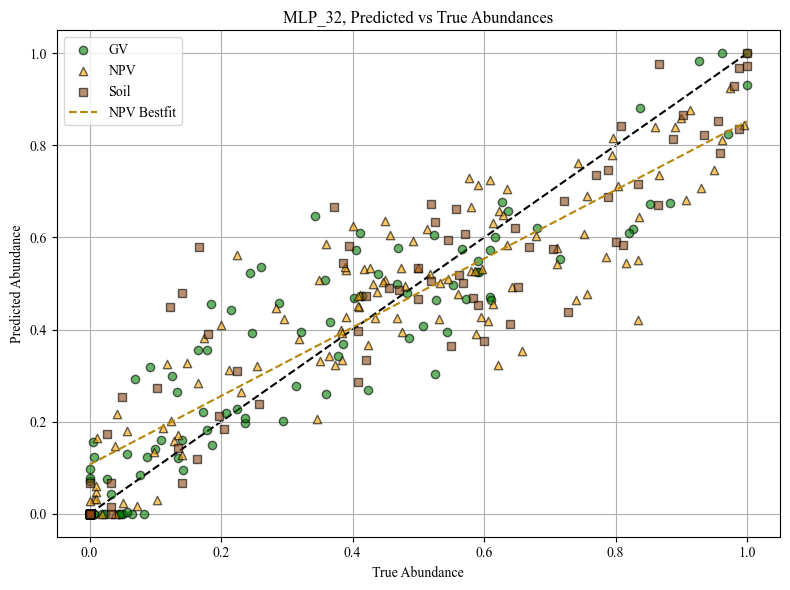

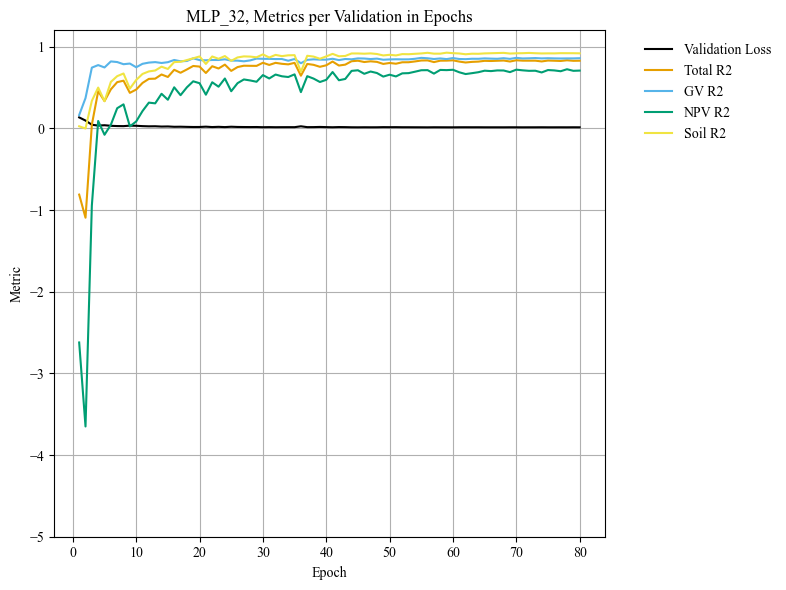

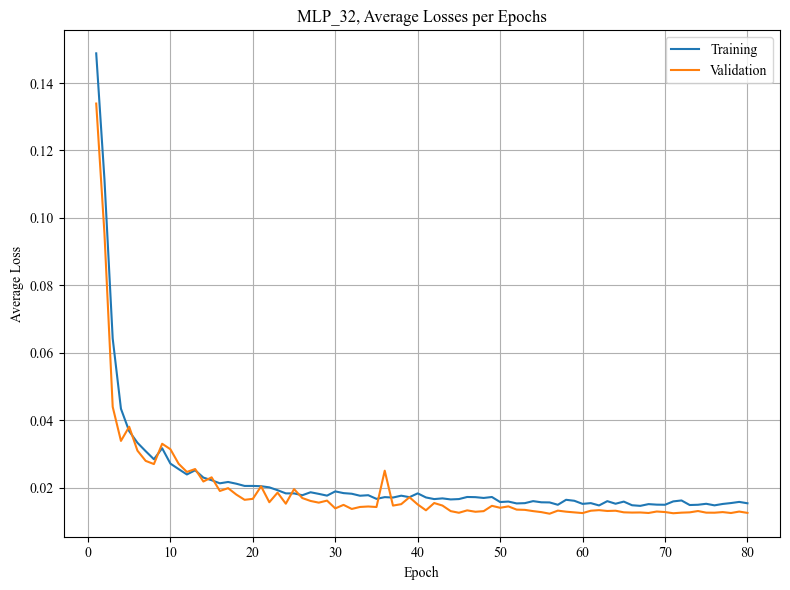

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.275352
Epoch 1/80, Step 2/47, Train Loss: 0.236352
Epoch 1/80, Step 3/47, Train Loss: 0.186393
Epoch 1/80, Step 4/47, Train Loss: 0.204222
Epoch 1/80, Step 5/47, Train Loss: 0.205327
Epoch 1/80, Step 6/47, Train Loss: 0.169852
Epoch 1/80, Step 7/47, Train Loss: 0.136770
Epoch 1/80, Step 8/47, Train Loss: 0.156591
Epoch 1/80, Step 9/47, Train Loss: 0.198455
Epoch 1/80, Step 10/47, Train Loss: 0.142788
Epoch 1/80, Step 11/47, Train Loss: 0.117294
Epoch 1/80, Step 12/47, Train Loss: 0.113867
Epoch 1/80, Step 13/47, Train Loss: 0.140155
Epoch 1/80, Step 14/47, Train Loss: 0.076370
Epoch 1/80, Step 15/47, Train Loss: 0.113186
Epoch 1/80, Step 16/47, Train Loss: 0.118394
Epoch 1/80, Step 17/47, Train Loss: 0.139198
Epoch 1/80, Step 18/47, Train Loss: 0.107044
Epoch 1/80, Step 19/47, Train Loss: 0.123162
Epoch 1/80, Step 20/47, Train Loss: 0.123895
Epoch 1/80, Step 21/47, Train Loss: 0.096863
Epoch 1/80, Step 22/47, Train Loss: 0.075219
Ep

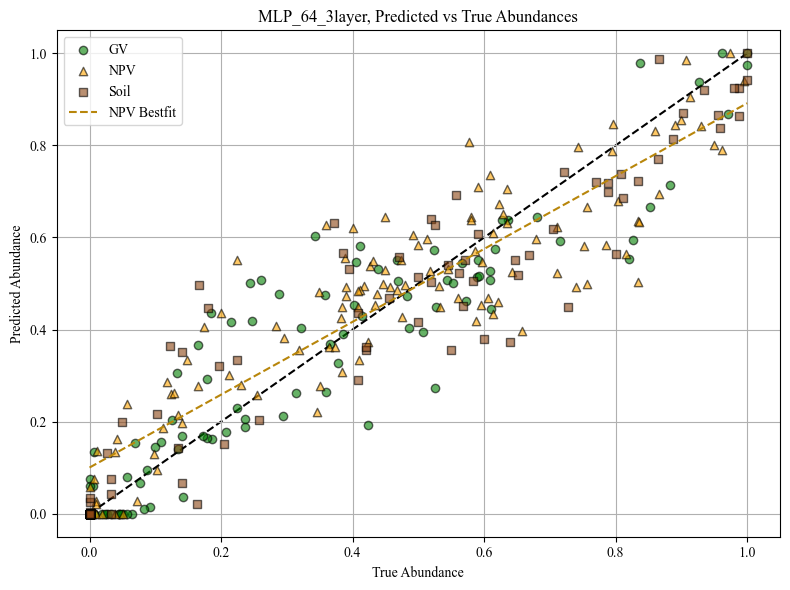

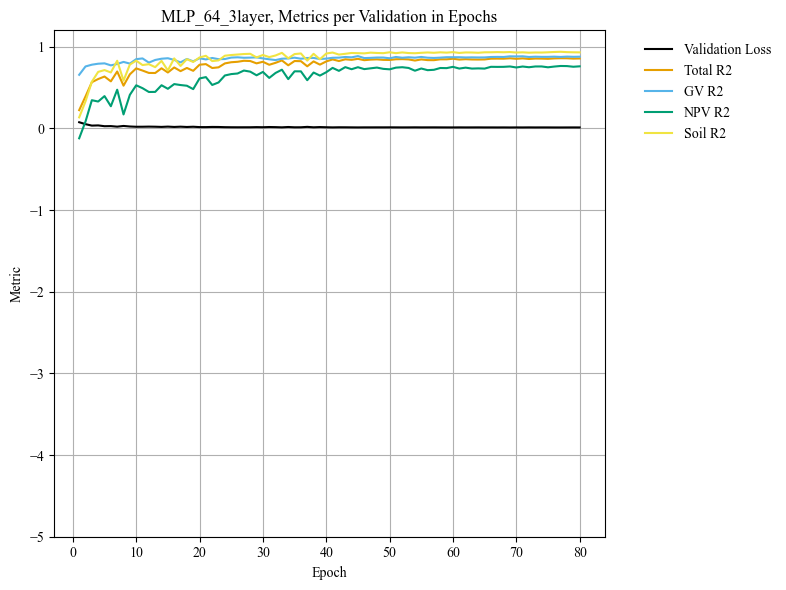

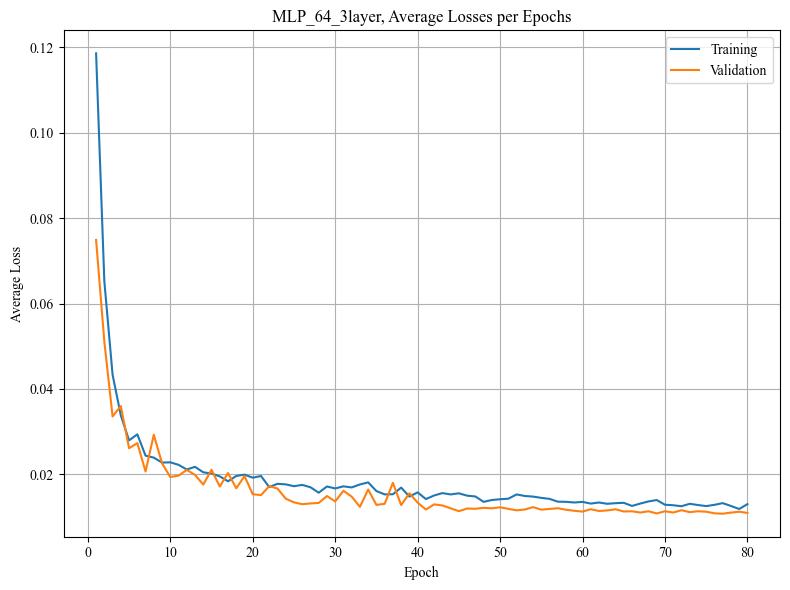

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.174155
Epoch 1/80, Step 2/47, Train Loss: 0.165973
Epoch 1/80, Step 3/47, Train Loss: 0.142560
Epoch 1/80, Step 4/47, Train Loss: 0.140511
Epoch 1/80, Step 5/47, Train Loss: 0.139661
Epoch 1/80, Step 6/47, Train Loss: 0.093141
Epoch 1/80, Step 7/47, Train Loss: 0.081130
Epoch 1/80, Step 8/47, Train Loss: 0.126526
Epoch 1/80, Step 9/47, Train Loss: 0.080888
Epoch 1/80, Step 10/47, Train Loss: 0.086480
Epoch 1/80, Step 11/47, Train Loss: 0.084605
Epoch 1/80, Step 12/47, Train Loss: 0.063672
Epoch 1/80, Step 13/47, Train Loss: 0.060340
Epoch 1/80, Step 14/47, Train Loss: 0.068946
Epoch 1/80, Step 15/47, Train Loss: 0.059469
Epoch 1/80, Step 16/47, Train Loss: 0.075938
Epoch 1/80, Step 17/47, Train Loss: 0.048062
Epoch 1/80, Step 18/47, Train Loss: 0.049442
Epoch 1/80, Step 19/47, Train Loss: 0.044257
Epoch 1/80, Step 20/47, Train Loss: 0.052729
Epoch 1/80, Step 21/47, Train Loss: 0.050349
Epoch 1/80, Step 22/47, Train Loss: 0.035155
Ep

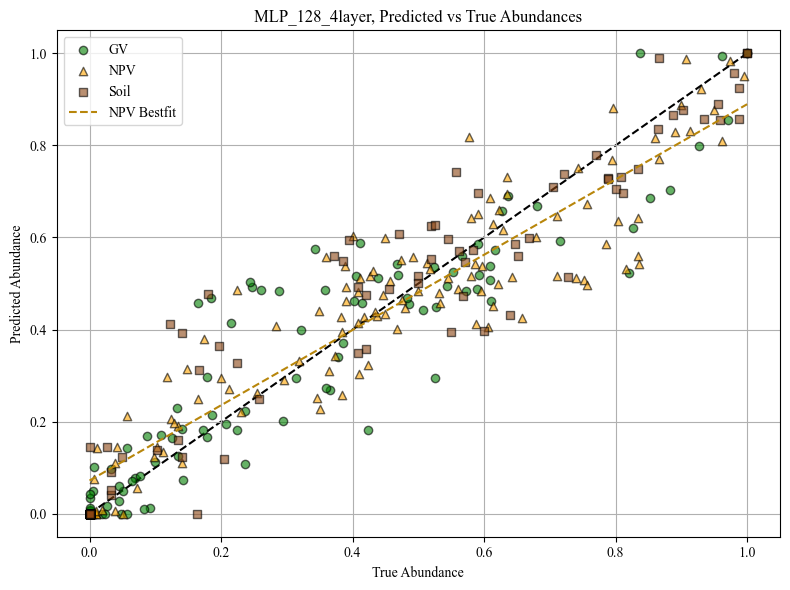

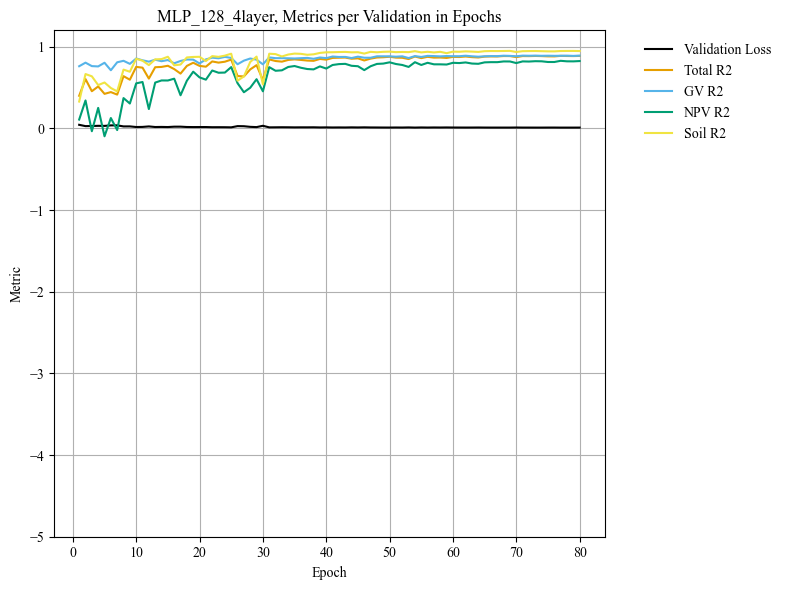

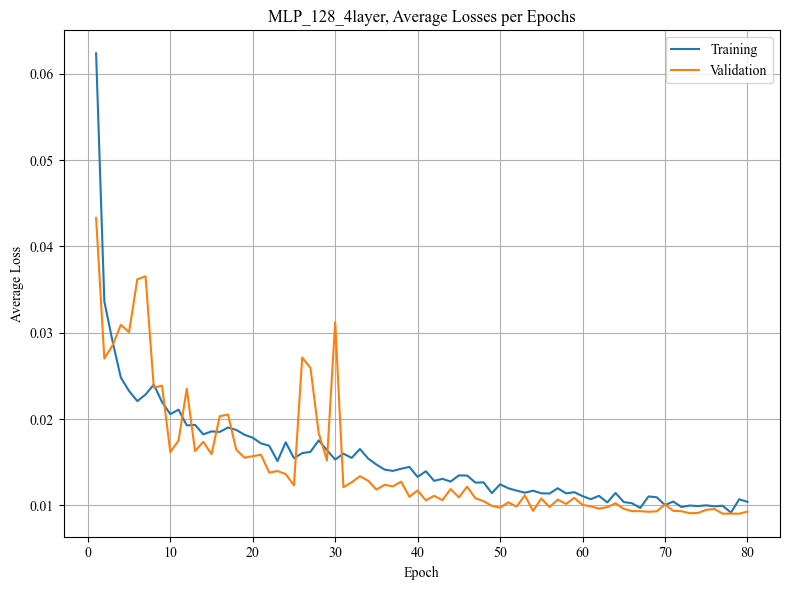

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.275860
Epoch 1/80, Step 2/47, Train Loss: 0.183703
Epoch 1/80, Step 3/47, Train Loss: 0.086522
Epoch 1/80, Step 4/47, Train Loss: 0.113892
Epoch 1/80, Step 5/47, Train Loss: 0.113097
Epoch 1/80, Step 6/47, Train Loss: 0.082219
Epoch 1/80, Step 7/47, Train Loss: 0.072704
Epoch 1/80, Step 8/47, Train Loss: 0.091498
Epoch 1/80, Step 9/47, Train Loss: 0.112519
Epoch 1/80, Step 10/47, Train Loss: 0.091251
Epoch 1/80, Step 11/47, Train Loss: 0.070996
Epoch 1/80, Step 12/47, Train Loss: 0.067395
Epoch 1/80, Step 13/47, Train Loss: 0.072385
Epoch 1/80, Step 14/47, Train Loss: 0.089178
Epoch 1/80, Step 15/47, Train Loss: 0.048262
Epoch 1/80, Step 16/47, Train Loss: 0.084747
Epoch 1/80, Step 17/47, Train Loss: 0.038117
Epoch 1/80, Step 18/47, Train Loss: 0.050515
Epoch 1/80, Step 19/47, Train Loss: 0.043318
Epoch 1/80, Step 20/47, Train Loss: 0.062795
Epoch 1/80, Step 21/47, Train Loss: 0.079513
Epoch 1/80, Step 22/47, Train Loss: 0.058483
Ep

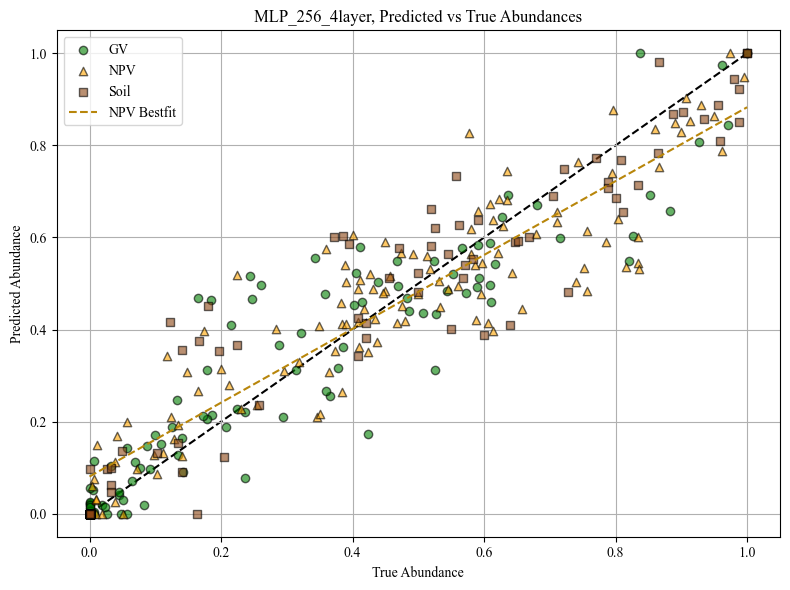

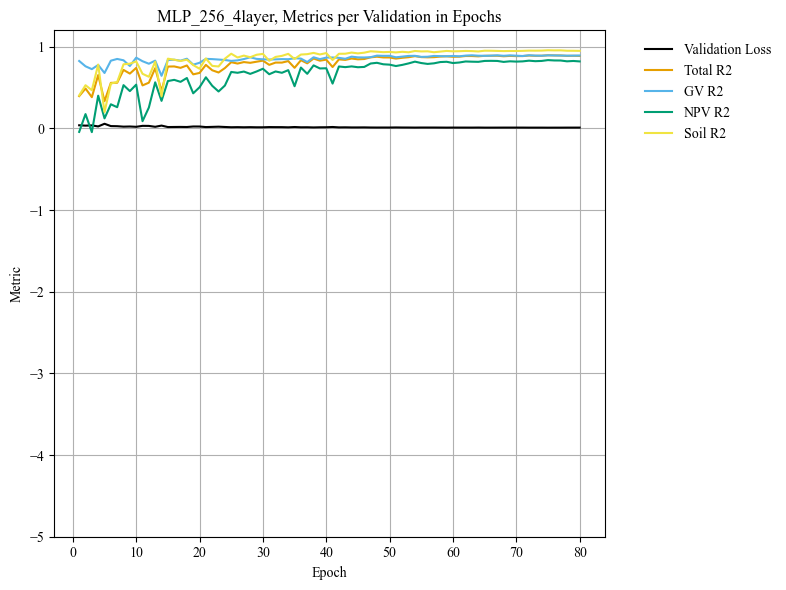

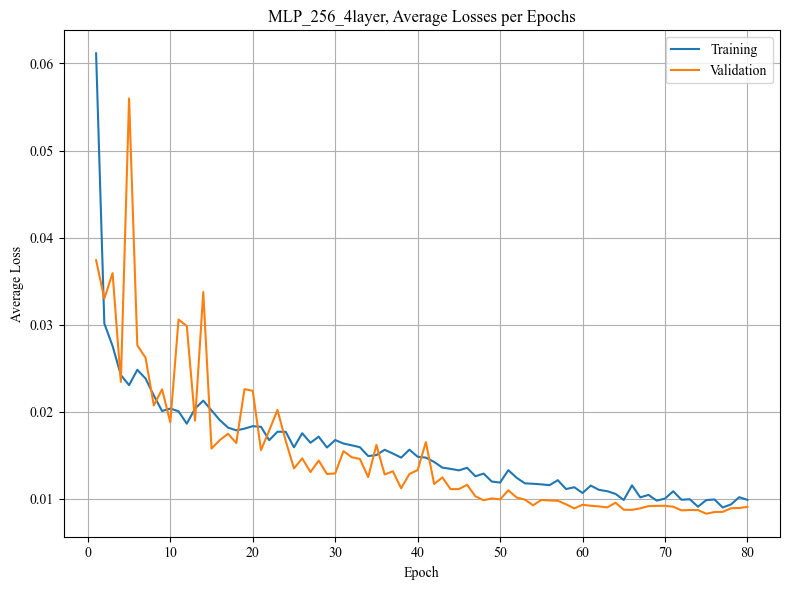

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.245887
Epoch 1/80, Step 2/47, Train Loss: 0.116352
Epoch 1/80, Step 3/47, Train Loss: 0.108213
Epoch 1/80, Step 4/47, Train Loss: 0.103224
Epoch 1/80, Step 5/47, Train Loss: 0.132126
Epoch 1/80, Step 6/47, Train Loss: 0.067859
Epoch 1/80, Step 7/47, Train Loss: 0.099183
Epoch 1/80, Step 8/47, Train Loss: 0.068497
Epoch 1/80, Step 9/47, Train Loss: 0.082582
Epoch 1/80, Step 10/47, Train Loss: 0.081962
Epoch 1/80, Step 11/47, Train Loss: 0.086581
Epoch 1/80, Step 12/47, Train Loss: 0.093022
Epoch 1/80, Step 13/47, Train Loss: 0.058861
Epoch 1/80, Step 14/47, Train Loss: 0.057242
Epoch 1/80, Step 15/47, Train Loss: 0.072691
Epoch 1/80, Step 16/47, Train Loss: 0.044084
Epoch 1/80, Step 17/47, Train Loss: 0.032830
Epoch 1/80, Step 18/47, Train Loss: 0.048545
Epoch 1/80, Step 19/47, Train Loss: 0.066909
Epoch 1/80, Step 20/47, Train Loss: 0.045192
Epoch 1/80, Step 21/47, Train Loss: 0.040245
Epoch 1/80, Step 22/47, Train Loss: 0.056821
Ep

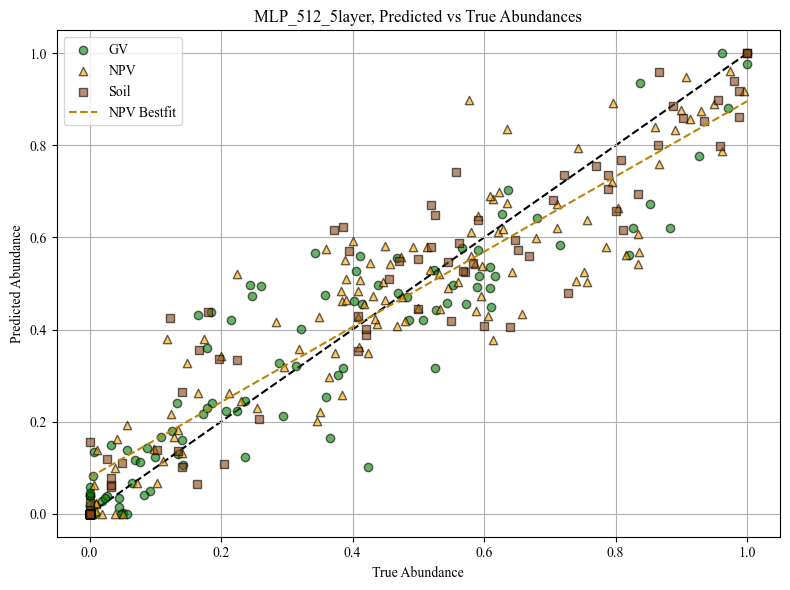

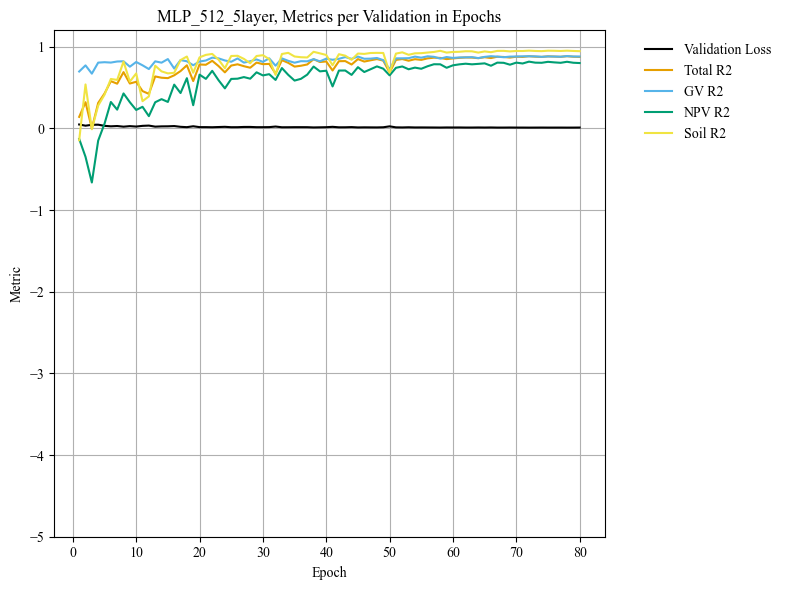

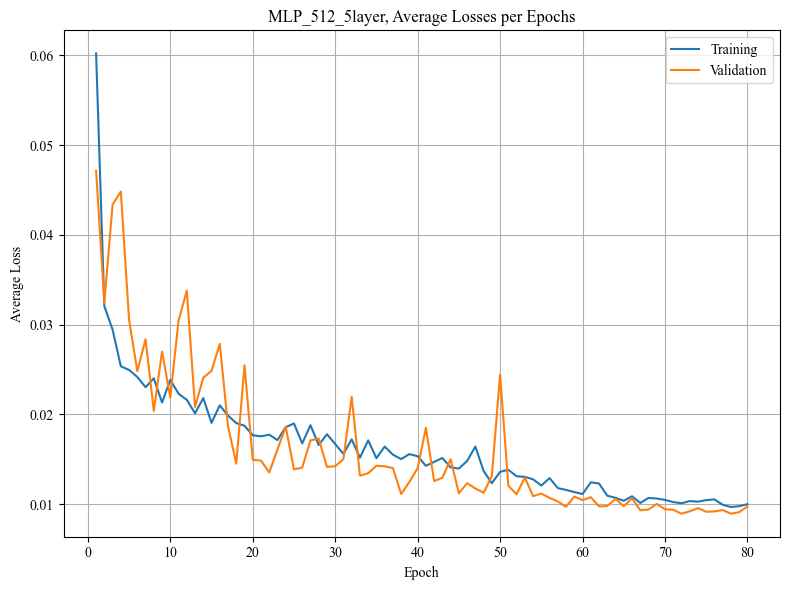

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.241853
Epoch 1/80, Step 2/47, Train Loss: 0.218688
Epoch 1/80, Step 3/47, Train Loss: 0.263261
Epoch 1/80, Step 4/47, Train Loss: 0.201479
Epoch 1/80, Step 5/47, Train Loss: 0.186572
Epoch 1/80, Step 6/47, Train Loss: 0.213261
Epoch 1/80, Step 7/47, Train Loss: 0.134942
Epoch 1/80, Step 8/47, Train Loss: 0.170601
Epoch 1/80, Step 9/47, Train Loss: 0.113695
Epoch 1/80, Step 10/47, Train Loss: 0.195667
Epoch 1/80, Step 11/47, Train Loss: 0.146479
Epoch 1/80, Step 12/47, Train Loss: 0.133910
Epoch 1/80, Step 13/47, Train Loss: 0.095407
Epoch 1/80, Step 14/47, Train Loss: 0.076603
Epoch 1/80, Step 15/47, Train Loss: 0.113888
Epoch 1/80, Step 16/47, Train Loss: 0.155332
Epoch 1/80, Step 17/47, Train Loss: 0.154435
Epoch 1/80, Step 18/47, Train Loss: 0.135932
Epoch 1/80, Step 19/47, Train Loss: 0.089623
Epoch 1/80, Step 20/47, Train Loss: 0.111510
Epoch 1/80, Step 21/47, Train Loss: 0.142924
Epoch 1/80, Step 22/47, Train Loss: 0.137921
Ep

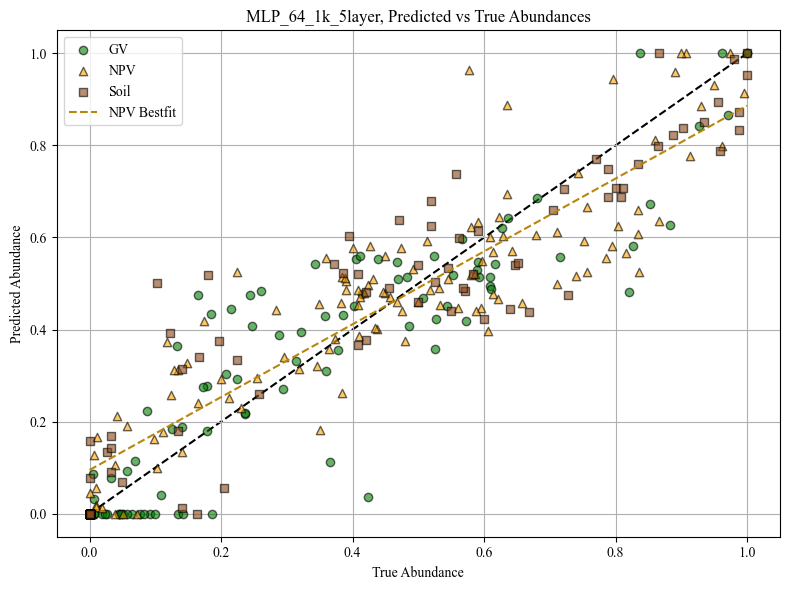

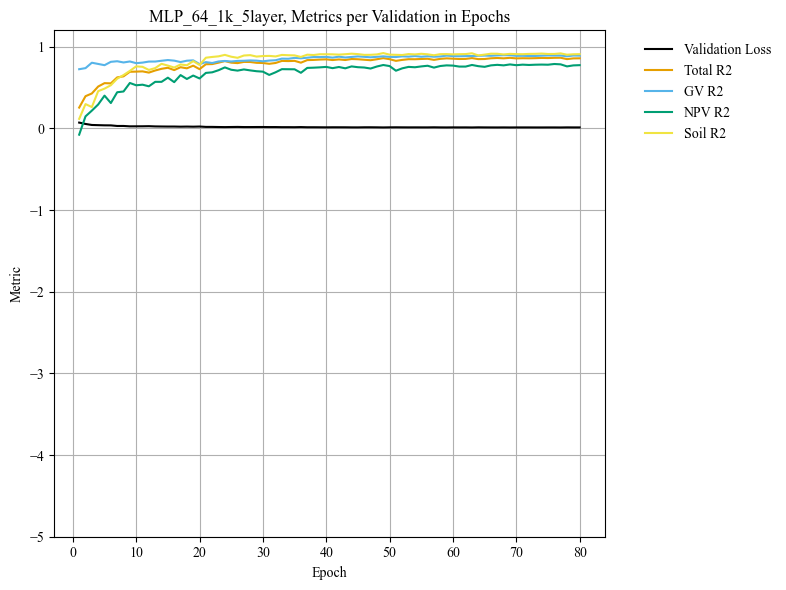

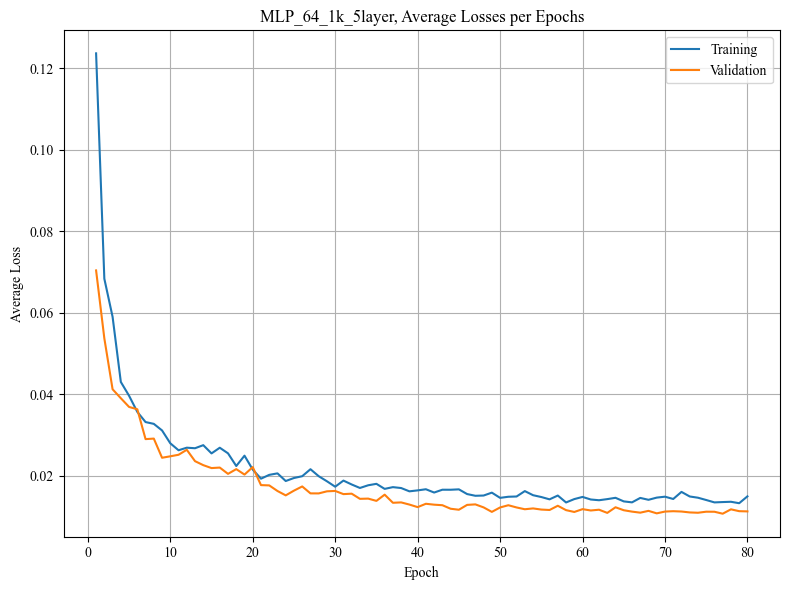

Testing complete
Epoch 1/80, Step 1/47, Train Loss: 0.178810
Epoch 1/80, Step 2/47, Train Loss: 0.135639
Epoch 1/80, Step 3/47, Train Loss: 0.152380
Epoch 1/80, Step 4/47, Train Loss: 0.147156
Epoch 1/80, Step 5/47, Train Loss: 0.157465
Epoch 1/80, Step 6/47, Train Loss: 0.064164
Epoch 1/80, Step 7/47, Train Loss: 0.134417
Epoch 1/80, Step 8/47, Train Loss: 0.116203
Epoch 1/80, Step 9/47, Train Loss: 0.124342
Epoch 1/80, Step 10/47, Train Loss: 0.079319
Epoch 1/80, Step 11/47, Train Loss: 0.119978
Epoch 1/80, Step 12/47, Train Loss: 0.129290
Epoch 1/80, Step 13/47, Train Loss: 0.086288
Epoch 1/80, Step 14/47, Train Loss: 0.071006
Epoch 1/80, Step 15/47, Train Loss: 0.104721
Epoch 1/80, Step 16/47, Train Loss: 0.102121
Epoch 1/80, Step 17/47, Train Loss: 0.117961
Epoch 1/80, Step 18/47, Train Loss: 0.093643
Epoch 1/80, Step 19/47, Train Loss: 0.104230
Epoch 1/80, Step 20/47, Train Loss: 0.080565
Epoch 1/80, Step 21/47, Train Loss: 0.104751
Epoch 1/80, Step 22/47, Train Loss: 0.081973
Ep

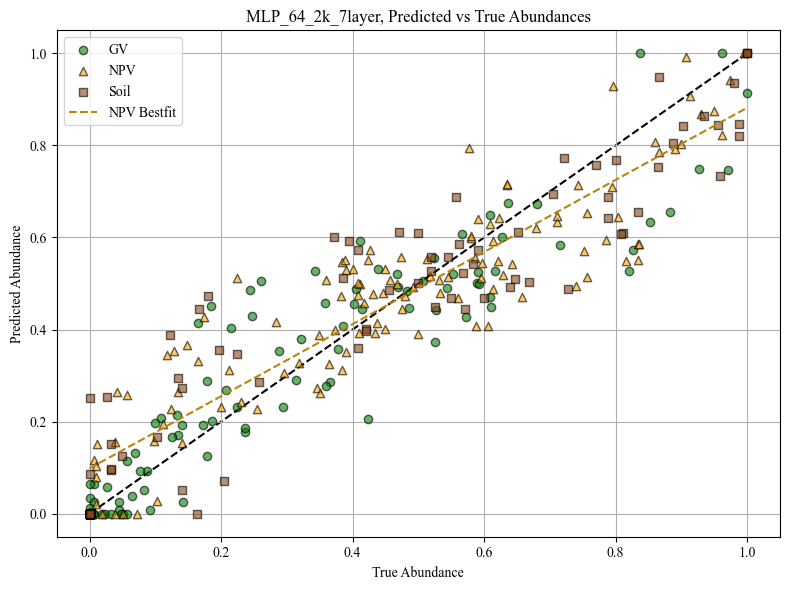

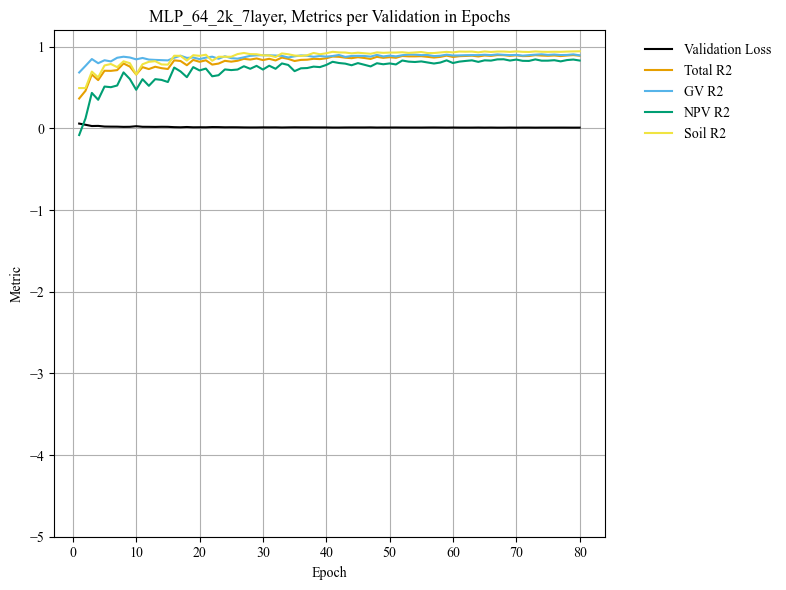

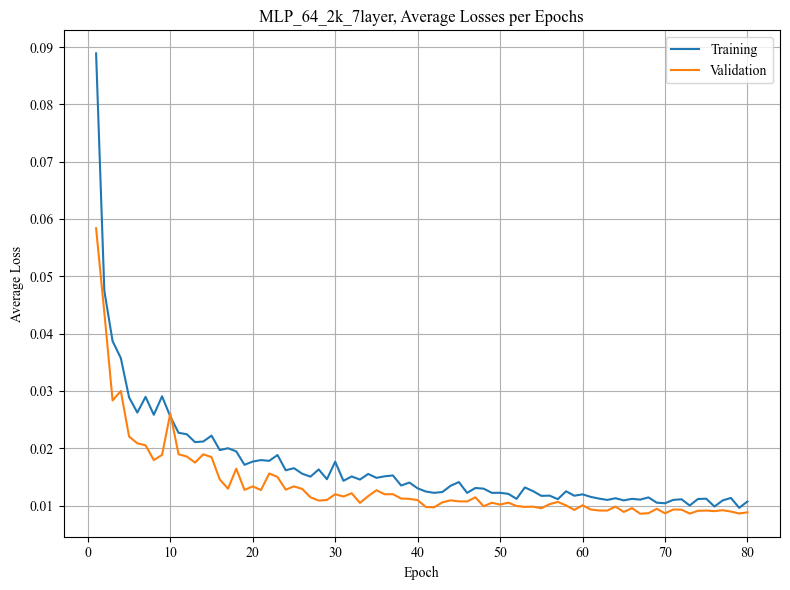

Testing complete


In [8]:
mlp_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32)
    model = MLP(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    mlp_dict[model_name] = model_dict

In [9]:
import pickle
with open('mlp_dict.pkl', 'wb') as fp:
    pickle.dump(mlp_dict, fp)

In [12]:
# Best model
print(mlp_dict['MLP_128_4layer']['metrics_total'])

[[6.13150000e+04 1.19552000e+05 9.58395004e-03 8.71570528e-01
  8.75596166e-01 8.03691208e-01 9.35424089e-01 6.40384182e-02
  6.11597858e-02 8.28357860e-02 4.81196754e-02]]


In [11]:
for i in mlp_dict.keys():
    print(f"For {i}, NPV R2: {mlp_dict[i]['metrics_total'][0][5]}, param#: {mlp_dict[i]['metrics_total'][0][0]}")

For MLP_32, NPV R2: 0.6955884099006653, param#: 3875.0
For MLP_64_3layer, NPV R2: 0.761926531791687, param#: 14083.0
For MLP_128_4layer, NPV R2: 0.8036912083625793, param#: 61315.0
For MLP_256_4layer, NPV R2: 0.7890418767929077, param#: 220931.0
For MLP_512_5layer, NPV R2: 0.7889518141746521, param#: 1098755.0
For MLP_64_1k_5layer, NPV R2: 0.7468029260635376, param#: 3294787.0
For MLP_64_2k_7layer, NPV R2: 0.771522581577301, param#: 25470531.0
